In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [ ]:
# Example placeholder (REMOVE if you already have X, y)
X = np.load('../data/X_features.npy')
y = np.load('../data/y_labels.npy')
# Encode labels (happy, sad → numbers)
le = LabelEncoder()
y = le.fit_transform(y)
# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
class MultiClassSVM:
    def __init__(self, learning_rate=0.001, epochs=1000, lambda_param=0.01):
        self.lr = learning_rate
        self.epochs = epochs
        self.lambda_param = lambda_param
        self.classes = None
        self.weights = None
        self.bias = None
        self.losses = []

    def hinge_loss(self, y_true, scores):
        return np.mean(np.maximum(0, 1 - y_true * scores))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        self.weights = np.zeros((n_classes, n_features))
        self.bias = np.zeros(n_classes)

        for epoch in range(self.epochs):
            total_loss = 0

            for idx, cls in enumerate(self.classes):
                y_binary = np.where(y == cls, 1, -1)

                for i in range(n_samples):
                    condition = y_binary[i] * (np.dot(X[i], self.weights[idx]) + self.bias[idx]) >= 1

                    if condition:
                        dw = 2 * self.lambda_param * self.weights[idx]
                        db = 0
                    else:
                        dw = 2 * self.lambda_param * self.weights[idx] - y_binary[i] * X[i]
                        db = -y_binary[i]

                    self.weights[idx] -= self.lr * dw
                    self.bias[idx] -= self.lr * db

                scores = np.dot(X, self.weights[idx]) + self.bias[idx]
                total_loss += self.hinge_loss(y_binary, scores)

            avg_loss = total_loss / n_classes
            self.losses.append(avg_loss)

            if epoch % 100 == 0:
                print(f'Epoch {epoch}/{self.epochs} — Loss: {avg_loss:.4f}')

    def predict(self, X):
        scores = np.dot(X, self.weights.T) + self.bias
        class_indices = np.argmax(scores, axis=1)
        return self.classes[class_indices]

In [4]:
model = MultiClassSVM(learning_rate=0.001, epochs=1000, lambda_param=0.01)
model.fit(X_train, y_train)

Epoch 0/1000 — Loss: 0.2449
Epoch 100/1000 — Loss: 0.1797
Epoch 200/1000 — Loss: 0.1792
Epoch 300/1000 — Loss: 0.1793
Epoch 400/1000 — Loss: 0.1793
Epoch 500/1000 — Loss: 0.1792
Epoch 600/1000 — Loss: 0.1796
Epoch 700/1000 — Loss: 0.1793
Epoch 800/1000 — Loss: 0.1796
Epoch 900/1000 — Loss: 0.1794


In [5]:
y_pred = model.predict(X_test)

In [6]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-Score:  {f1:.4f}')

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy:  0.6510
Precision: 0.6554
Recall:    0.6510
F1-Score:  0.6451

Classification Report:
              precision    recall  f1-score   support

       angry       0.74      0.75      0.74        79
        calm       0.58      0.81      0.67        69
     disgust       0.69      0.48      0.56        84
     fearful       0.78      0.70      0.74        80
       happy       0.64      0.66      0.65        82
     neutral       0.57      0.38      0.46        42
         sad       0.52      0.49      0.50        61
   surprised       0.65      0.81      0.72        79

    accuracy                           0.65       576
   macro avg       0.64      0.63      0.63       576
weighted avg       0.66      0.65      0.65       576



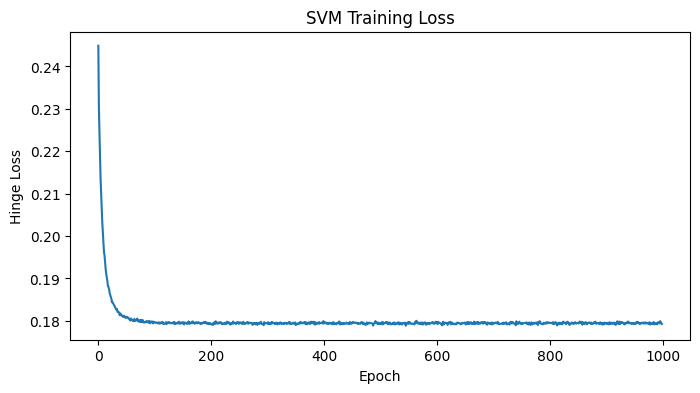

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(model.losses)
plt.title('SVM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Hinge Loss')
plt.show()

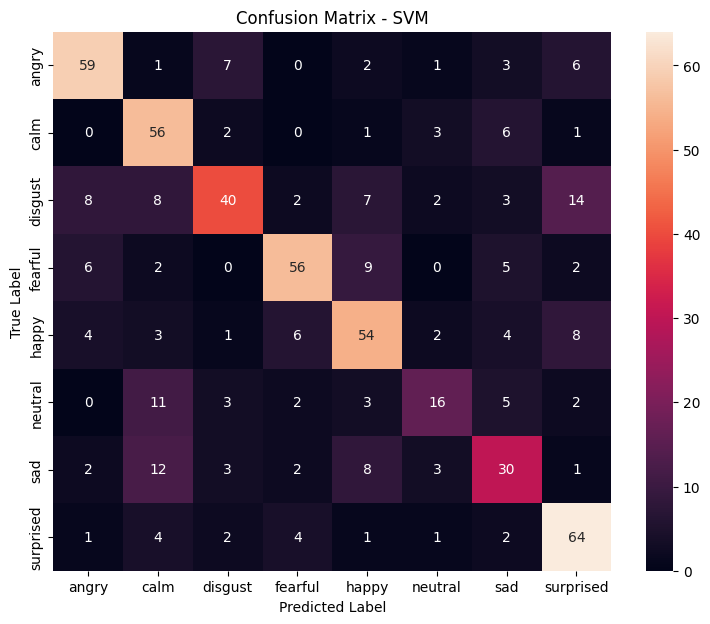

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title('Confusion Matrix - SVM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [9]:
os.makedirs('../models', exist_ok=True)

np.save('../models/svm_weights.npy', model.weights)
np.save('../models/svm_bias.npy', model.bias)
joblib.dump(scaler, '../models/svm_scaler.pkl')
joblib.dump(le, '../models/svm_label_encoder.pkl')

print("SVM model saved.")

SVM model saved.
